In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/GlobalWeatherRepository.csv")

In [3]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [4]:
df.shape

(141898, 41)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 141898 entries, 0 to 141897
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       141898 non-null  str    
 1   location_name                 141898 non-null  str    
 2   latitude                      141898 non-null  float64
 3   longitude                     141898 non-null  float64
 4   timezone                      141898 non-null  str    
 5   last_updated_epoch            141898 non-null  int64  
 6   last_updated                  141898 non-null  str    
 7   temperature_celsius           141898 non-null  float64
 8   temperature_fahrenheit        141898 non-null  float64
 9   condition_text                141898 non-null  str    
 10  wind_mph                      141898 non-null  float64
 11  wind_kph                      141898 non-null  float64
 12  wind_degree                   141898 non-null  int64  


In [6]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,141898.000000,141898.000000,1.418980e+05,141898.000000,141898.000000,141898.000000,141898.000000,141898.000000,141898.000000,141898.000000,...,141898.000000,141898.000000,141898.000000,141898.000000,141898.000000,141898.000000,141898.000000,141898.000000,141898.000000,141898.000000
mean,19.217561,21.936584,1.747429e+09,21.240351,70.234421,7.985723,12.855474,168.900457,1014.032305,29.943772,...,18.190038,451.532426,57.666021,14.839068,10.148748,23.886912,47.814833,1.688100,2.579825,49.789588
std,24.412558,65.783030,1.822806e+07,9.642924,17.357138,7.130881,11.472739,103.670517,10.198548,0.301107,...,13.695278,745.647954,30.467352,23.383985,34.900177,36.329237,147.560876,0.934299,2.424787,35.083443
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731661e+09,15.500000,60.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.200000,196.850000,38.000000,1.750000,1.110000,7.030000,9.850000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747472e+09,23.700000,74.700000,6.700000,10.800000,161.000000,1013.000000,29.930000,...,15.300000,288.600000,55.000000,5.735000,2.405000,13.950000,19.610000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.763192e+09,28.000000,82.300000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.100000,453.250000,73.000000,17.100000,8.140000,27.380000,40.885000,2.000000,3.000000,85.000000
max,64.150000,179.220000,1.778998e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [7]:
df.isnull().sum().sort_values(ascending=False)

country                         0
feels_like_fahrenheit           0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
air_quality_us-epa-index        0
air_quality_gb-defra-index      0
sunrise                         0
sunset                          0
moonrise                        0
moonset                         0
moon_phase                      0
visibility_km                   0
feels_like_celsius              0
location_name                   0
cloud                           0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fa

# Data Understanding

## Initial Observations

- Dataset contains 141,898 weather observations across global cities.
- Includes 41 weather-related features including temperature, humidity, precipitation, air quality, and wind metrics.
- No missing values were detected during initial inspection.
- The dataset includes temporal features (`last_updated`, `last_updated_epoch`) suitable for time-series forecasting.
- Temperature in Celsius was selected as the primary forecasting target.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 141898 entries, 0 to 141897
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       141898 non-null  str           
 1   location_name                 141898 non-null  str           
 2   latitude                      141898 non-null  float64       
 3   longitude                     141898 non-null  float64       
 4   timezone                      141898 non-null  str           
 5   last_updated_epoch            141898 non-null  int64         
 6   last_updated                  141898 non-null  datetime64[us]
 7   temperature_celsius           141898 non-null  float64       
 8   temperature_fahrenheit        141898 non-null  float64       
 9   condition_text                141898 non-null  str           
 10  wind_mph                      141898 non-null  float64       
 11  wind_kph                

# Exploratory Data Analysis (EDA)

The goal of this section is to explore trends, distributions, relationships, and patterns in the global weather dataset through statistical summaries and visualizations.

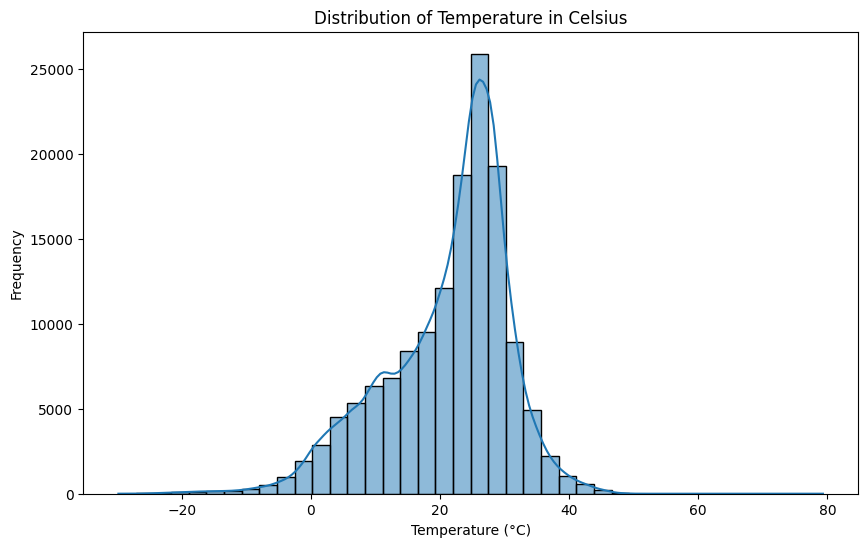

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(df['temperature_celsius'], bins=40, kde=True)

plt.title('Distribution of Temperature in Celsius')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')

plt.show()

## Temperature Distribution Insights

- The histogram shows the distribution of global temperature observations.
- Most temperatures appear concentrated within moderate climate ranges.
- Extreme low and high temperatures may represent geographical or seasonal variations.

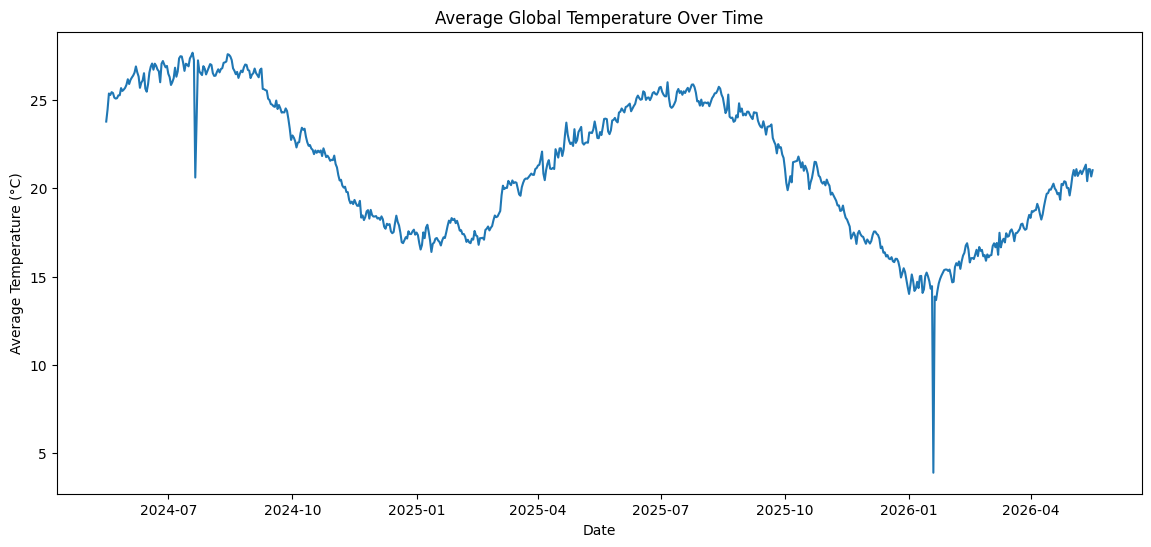

In [15]:
daily_temp = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean()

plt.figure(figsize=(14,6))

daily_temp.plot()

plt.title('Average Global Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')

plt.show()

## Correlation Analysis

This section explores relationships between numerical weather variables to identify patterns and features that may influence temperature forecasting.

In [16]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])

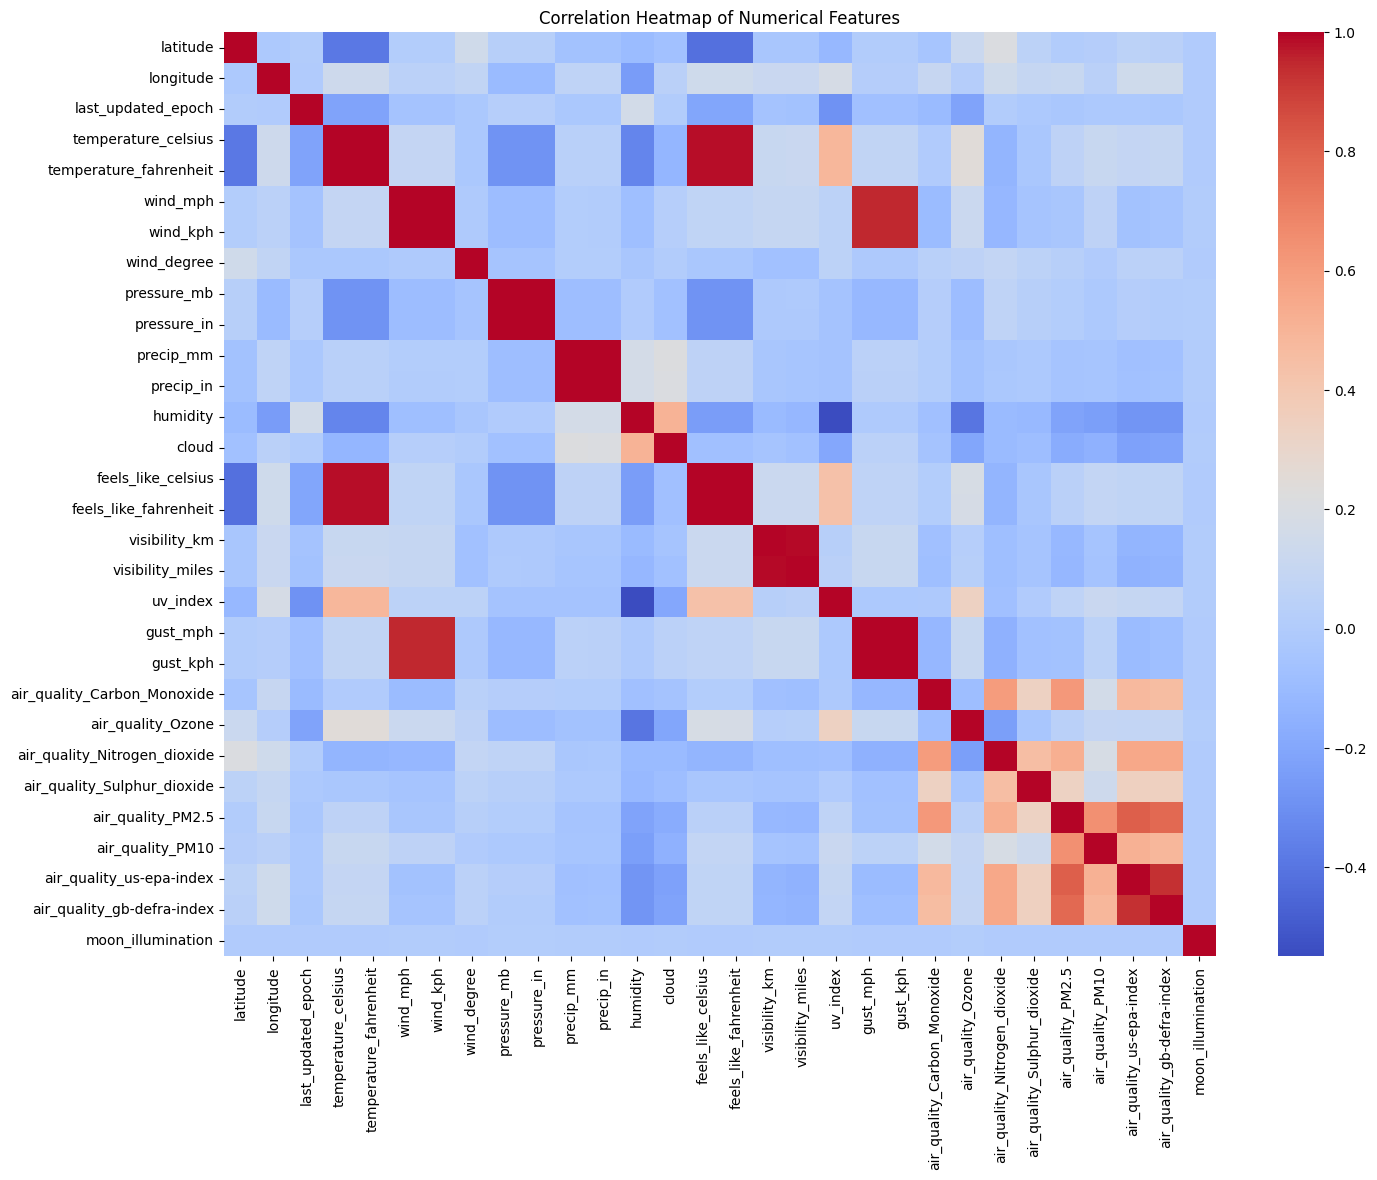

In [17]:
plt.figure(figsize=(16, 12))

correlation_matrix = numerical_df.corr()

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap of Numerical Features')

plt.show()

## Outlier Detection

This section identifies extreme weather observations and potential anomalies in temperature data using boxplots and statistical analysis.

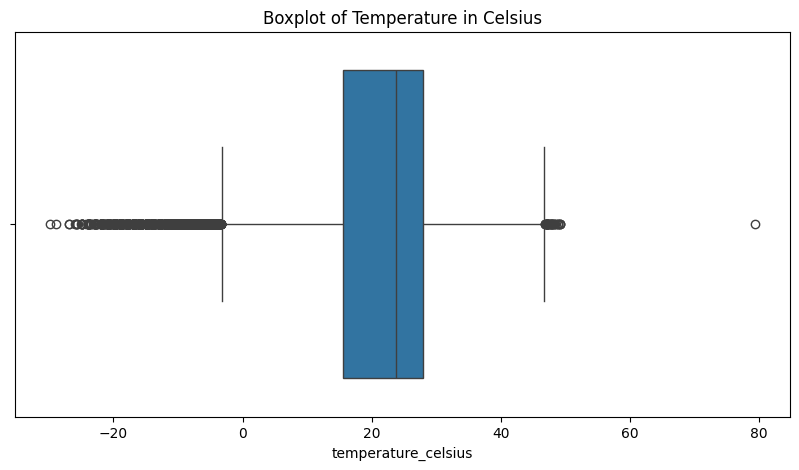

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['temperature_celsius'])

plt.title('Boxplot of Temperature in Celsius')

plt.show()

In [19]:
Q1 = df['temperature_celsius'].quantile(0.25)
Q3 = df['temperature_celsius'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['temperature_celsius'] < lower_bound) |
    (df['temperature_celsius'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 1975


## Outlier Analysis Insights

- Boxplot analysis revealed several extreme temperature observations.
- Using the IQR method, approximately 1,975 temperature outliers were identified.
- These observations were retained because extreme weather conditions may represent valid climate events rather than data errors.
- Outlier analysis is important for understanding unusual environmental patterns and improving forecasting robustness.

## Precipitation Analysis

This section explores rainfall distribution and precipitation patterns across global weather observations.

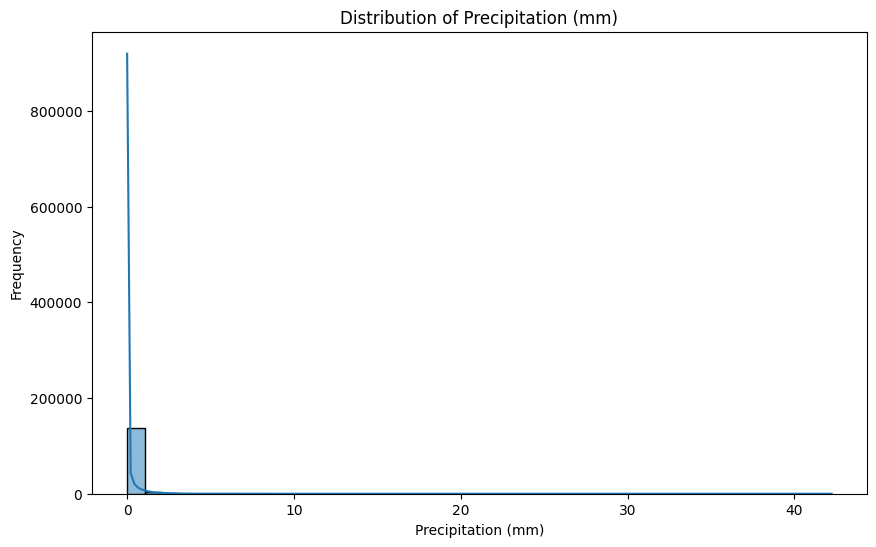

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(df['precip_mm'], bins=40, kde=True)

plt.title('Distribution of Precipitation (mm)')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency')

plt.show()

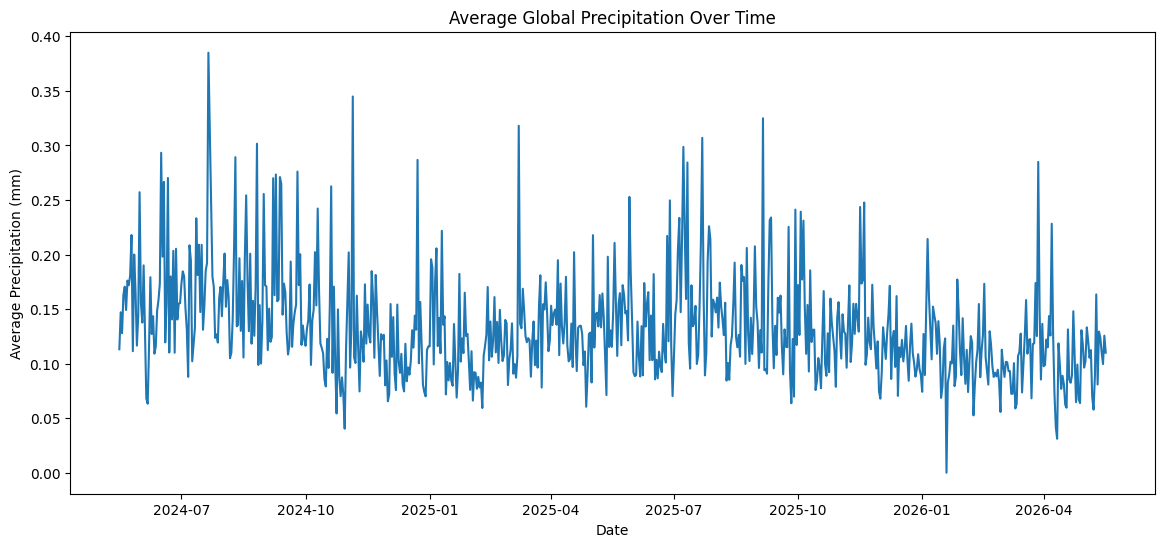

In [21]:
daily_precip = df.groupby(df['last_updated'].dt.date)['precip_mm'].mean()

plt.figure(figsize=(14,6))

daily_precip.plot()

plt.title('Average Global Precipitation Over Time')
plt.xlabel('Date')
plt.ylabel('Average Precipitation (mm)')

plt.show()

## Precipitation Analysis Insights

- Precipitation values are highly right-skewed, with most observations concentrated near zero rainfall.
- A small number of observations show extreme precipitation events.
- The time-series visualization shows fluctuations in average global precipitation over time.
- These variations may reflect seasonal weather patterns and regional climate differences.